In [48]:
import numpy as np
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb13/chb13_55.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb13/chb13_58.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb13/chb13_21.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb13/chb13_40.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb13/chb13_62.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb13/chb13_19.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb13/chb13_60.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb13/chb13_59.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb14/chb14_19.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb14/chb14_27.edf
/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET/chb14/c

In [49]:
import mne

print(mne.__version__)

1.11.0


In [50]:

import os
import glob
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# EEG reading 
import mne
mne.set_log_level('WARNING')          

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

#Machine Learning 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Model Saving
import joblib

print(" All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

 All libraries imported successfully!
TensorFlow version: 2.19.0


In [51]:

DATASET_PATH = '/kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET'  
MAX_FILES_PER_PATIENT = 3    # limit files per patient to keep runtime reasonable
SAMPLE_RATE  = 256           # CHB-MIT standard sampling rate (Hz)
WINDOW_SEC   = 10            # seconds per EEG window
WINDOW_SIZE  = SAMPLE_RATE * WINDOW_SEC   # samples per window = 2560

print(f"Dataset path : {DATASET_PATH}")
print(f"Window size  : {WINDOW_SIZE} samples ({WINDOW_SEC}s @ {SAMPLE_RATE}Hz)")

Dataset path : /kaggle/input/datasets/eeshaaousaf/chb-mit-scalp-eeg-dataset/EEG_DATASET
Window size  : 2560 samples (10s @ 256Hz)


In [52]:
def find_edf_files(dataset_path, max_per_patient=None):
    """
    Walk the dataset directory and collect EDF file paths.
    Returns a dict  {patient_id: [list of edf paths]}
    """
    patient_files = {}

    # Each sub-directory is one patient (chb01, chb02, …)
    for patient_dir in sorted(os.listdir(dataset_path)):
        full_path = os.path.join(dataset_path, patient_dir)
        if not os.path.isdir(full_path):
            continue
        # Collect all .edf files inside this patient folder
        edfs = sorted(glob.glob(os.path.join(full_path, '*.edf')))
        if edfs:
            if max_per_patient:
                edfs = edfs[:max_per_patient]
            patient_files[patient_dir] = edfs

    return patient_files


# Load file index
patient_files = find_edf_files(DATASET_PATH)

# Flatten to a single list for easy counting
all_edf_files = [f for files in patient_files.values() for f in files]

print(f"Total patients  : {len(patient_files)}")
print(f"Total EDF files : {len(all_edf_files)}")
print("\nPatient → file count:")
for pid, files in patient_files.items():
    print(f"  {pid}: {len(files)} files")

Total patients  : 17
Total EDF files : 247

Patient → file count:
  chb01: 15 files
  chb02: 2 files
  chb03: 17 files
  chb05: 5 files
  chb06: 18 files
  chb07: 19 files
  chb08: 8 files
  chb09: 19 files
  chb10: 23 files
  chb12: 24 files
  chb13: 8 files
  chb14: 20 files
  chb15: 14 files
  chb16: 19 files
  chb20: 6 files
  chb23: 9 files
  chb24: 21 files


In [53]:
print("Patients:", len(patient_files))

total_files = sum(len(v) for v in patient_files.values())

print("Total EDF files:", total_files)

Patients: 17
Total EDF files: 247


In [54]:
import os
import numpy as np
import mne

def read_edf_signals(edf_path):
    """
    Read an EDF file using MNE.
    Returns:
        signals        -> numpy array (channels × samples)
        channel_names  -> list of channel names
        sample_rate    -> sampling frequency
        raw            -> MNE Raw object
    """

    try:
        # Load EDF file
        raw = mne.io.read_raw_edf(
            edf_path,
            preload=True,
            verbose=False
        )

        # Extract signal matrix
        signals = raw.get_data()

        # Channel names
        channel_names = raw.ch_names

        # Sampling rate
        sample_rate = int(raw.info['sfreq'])

        return signals, channel_names, sample_rate, raw

    except Exception as e:

        print(f"[SKIP] Could not read {os.path.basename(edf_path)}")
        print("ERROR:", e)

        return None, None, None, None



# ── FAST EEG Dataset Builder (Optimized) ──────────────────────────────────

X_list = []
y_list = []

processed_files = 0
skipped_files = 0

# Use only first 80 EDF files initially
subset_files = all_edf_files[:80]

for file_path in subset_files:

    print(f"Processing: {os.path.basename(file_path)}")

    signals, channels, sr, raw = read_edf_signals(file_path)

    # Skip unreadable files
    if signals is None:
        skipped_files += 1
        continue

    try:

        # ── Use only first 10 seconds ────────────────────────────────

        max_samples = sr * 10

        if signals.shape[1] > max_samples:
            signals = signals[:, :max_samples]

        # ── Statistical Features ─────────────────────────────────────

        means   = np.mean(signals, axis=1)
        stds    = np.std(signals, axis=1)
        mins    = np.min(signals, axis=1)
        maxs    = np.max(signals, axis=1)
        medians = np.median(signals, axis=1)
        vars_   = np.var(signals, axis=1)

        feature_vector = np.concatenate([
            means,
            stds,
            mins,
            maxs,
            medians,
            vars_
        ])

        X_list.append(feature_vector)

        # ── TEMPORARY LABELS ────────────────────────────────────────

        # Random temporary labels for pipeline testing
        label = np.random.randint(0, 2)

        y_list.append(label)

        processed_files += 1

    except Exception as e:

        print(f"[FEATURE ERROR] {os.path.basename(file_path)}")
        print(e)

        skipped_files += 1


# Convert to arrays 

X_raw = np.array(X_list)

y_raw = np.array(y_list)

print("\nDataset successfully created ")

print(f"Processed files : {processed_files}")

print(f"X_raw shape     : {X_raw.shape}")

print(f"y_raw shape     : {y_raw.shape}")

print("\nClass distribution:")

unique, counts = np.unique(y_raw, return_counts=True)

for u, c in zip(unique, counts):

    label = "Non-Seizure" if u == 0 else "Seizure"

    print(f"{label}: {c}")

Processing: chb01_01.edf
Processing: chb01_02.edf
Processing: chb01_03.edf
Processing: chb01_04.edf
Processing: chb01_05.edf
Processing: chb01_06.edf
Processing: chb01_07.edf
Processing: chb01_08.edf
Processing: chb01_09.edf
Processing: chb01_10.edf
Processing: chb01_11.edf
Processing: chb01_12.edf
Processing: chb01_13.edf
Processing: chb01_14.edf
Processing: chb01_15.edf
Processing: chb02_16.edf
Processing: chb02_19.edf
Processing: chb03_01.edf
Processing: chb03_02.edf
Processing: chb03_03.edf
Processing: chb03_04.edf
Processing: chb03_05.edf
Processing: chb03_06.edf
Processing: chb03_07.edf
Processing: chb03_08.edf
Processing: chb03_09.edf
Processing: chb03_10.edf
Processing: chb03_11.edf
Processing: chb03_12.edf
Processing: chb03_13.edf
Processing: chb03_14.edf
Processing: chb03_15.edf
Processing: chb03_16.edf
Processing: chb03_17.edf
Processing: chb05_06.edf
Processing: chb05_13.edf
Processing: chb05_16.edf
Processing: chb05_17.edf
Processing: chb05_22.edf
Processing: chb06_01.edf


In [55]:
print("Final dataset shape:")
print("X_raw:", X_raw.shape)
print("y_raw:", y_raw.shape)

Final dataset shape:
X_raw: (78, 138)
y_raw: (78,)


In [56]:
print("signals.shape:")
print(signals.shape)

print("\nchannels:")
print(channels)

print("\nSample rate:")
print(sr)

signals.shape:
(23, 2560)

channels:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']

Sample rate:
256


In [60]:
# ── Rebuild DataFrame using ALL processed files ───────────────────────────

n_ch_used = 23

stat_names = ['mean', 'std', 'min', 'max', 'median', 'var']

ch_labels = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9',
    'FT9-FT10', 'FT10-T8', 'T8-P8-1'
][:n_ch_used]


# Create feature column names

col_names = [
    f'{ch}_{stat}'
    for ch in ch_labels
    for stat in stat_names
]


# Adjust if feature count differs

col_names = col_names[:X_raw.shape[1]]

while len(col_names) < X_raw.shape[1]:

    col_names.append(f'feat_{len(col_names)}')


# ── Create FULL dataframe ────────────────────────────────────────────────

df = pd.DataFrame(X_raw, columns=col_names)

df['label'] = y_raw


print("DataFrame rebuilt successfully ")

print("df shape:", df.shape)

df.head()

DataFrame rebuilt successfully 
df shape: (78, 139)


,FP1-F7_mean,FP1-F7_std,FP1-F7_min,FP1-F7_max,FP1-F7_median,FP1-F7_var,F7-T7_mean,F7-T7_std,F7-T7_min,F7-T7_max,...,FT10-T8_max,FT10-T8_median,FT10-T8_var,T8-P8-1_mean,T8-P8-1_std,T8-P8-1_min,T8-P8-1_max,T8-P8-1_median,T8-P8-1_var,label
0,0.000002,2.728785e-06,1.168651e-06,8.678266e-07,3.322650e-06,2.333791e-06,1.062271e-07,8.023504e-07,1.789377e-06,-2.786935e-07,...,6.508502e-10,7.170450e-10,4.747615e-10,4.978906e-10,7.868801e-10,6.716168e-10,6.147851e-09,1.094472e-09,6.508502e-10,0
1,-0.000002,1.860501e-07,-3.408120e-07,2.661783e-07,-1.512973e-06,6.010379e-07,-2.838828e-08,-6.997863e-07,-1.433608e-06,8.775946e-08,...,6.888303e-10,4.051993e-09,5.740451e-10,4.033919e-10,7.538595e-10,7.933788e-10,8.644077e-09,1.183575e-09,6.888303e-10,0
2,0.000002,-9.777167e-07,2.594628e-07,-7.823565e-07,1.284035e-06,-4.151404e-08,-8.528694e-07,-1.309524e-07,1.666361e-06,2.214591e-07,...,7.369949e-10,1.308185e-09,1.975094e-09,1.028702e-09,7.666945e-10,3.107554e-10,8.772478e-10,2.529767e-10,7.369949e-10,0
3,-0.000001,-1.401252e-06,2.906746e-06,4.858059e-07,-1.382326e-06,7.764042e-07,1.168040e-06,3.478327e-07,-9.838217e-07,-3.467643e-07,...,9.161129e-10,1.547573e-09,1.365864e-09,1.831980e-09,6.767518e-10,7.930165e-10,1.495666e-09,3.550966e-10,9.161129e-10,1
4,-0.000001,-1.678877e-07,-6.842186e-07,4.906136e-06,-2.858669e-07,-2.211844e-06,4.018010e-06,1.187576e-06,-4.835165e-07,1.456044e-07,...,7.129596e-10,1.999347e-09,6.652863e-10,4.744989e-10,5.732055e-10,5.482487e-10,6.684179e-09,1.014164e-09,7.129596e-10,1


In [61]:
print("=== .info() ===")
df.info()

=== .info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Columns: 139 entries, FP1-F7_mean to label
dtypes: float64(138), int64(1)
memory usage: 84.8 KB


In [62]:
print("=== .describe() ===")
df.describe()

=== .describe() ===


,FP1-F7_mean,FP1-F7_std,FP1-F7_min,FP1-F7_max,FP1-F7_median,FP1-F7_var,F7-T7_mean,F7-T7_std,F7-T7_min,F7-T7_max,...,FT10-T8_max,FT10-T8_median,FT10-T8_var,T8-P8-1_mean,T8-P8-1_std,T8-P8-1_min,T8-P8-1_max,T8-P8-1_median,T8-P8-1_var,label
count,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,...,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,7.800000e+01,78.000000
mean,-1.657940e-07,3.085454e-07,-3.800366e-08,-1.929280e-07,-1.031589e-08,1.940590e-07,-8.946182e-09,-2.415352e-07,-2.777680e-07,5.360528e-07,...,2.919473e-09,3.450290e-09,3.586315e-09,3.538588e-09,2.827216e-09,3.528108e-09,3.085186e-09,2.572293e-09,2.919473e-09,0.500000
std,3.415719e-06,4.386151e-06,3.548086e-06,2.190060e-06,3.451669e-06,1.382163e-06,2.314910e-06,3.150682e-06,4.502149e-06,3.091558e-06,...,5.029030e-09,8.529580e-09,5.461350e-09,6.341307e-09,5.725737e-09,8.169717e-09,3.839264e-09,7.057219e-09,5.029030e-09,0.503236
min,-2.217796e-05,-1.804258e-05,-2.242292e-05,-8.704670e-06,-2.119002e-05,-4.343559e-06,-1.401770e-05,-1.700824e-05,-3.236523e-05,-3.324176e-06,...,6.197210e-11,6.640432e-11,8.119865e-11,6.043435e-11,4.315679e-11,4.386823e-11,6.314345e-11,4.852641e-11,6.197210e-11,0.000000
25%,-7.965507e-07,-3.365003e-07,-2.575931e-07,-2.601496e-07,-6.790675e-07,-3.017399e-07,-5.211767e-07,-4.165904e-07,-9.360119e-07,-4.652396e-07,...,3.632537e-10,3.370758e-10,4.365719e-10,4.439888e-10,2.840544e-10,2.103319e-10,4.345600e-10,2.765482e-10,3.632537e-10,0.000000
50%,4.977869e-07,9.096459e-08,1.362943e-07,2.888431e-07,2.575549e-07,3.605006e-07,1.627747e-07,2.235195e-07,1.759005e-07,1.604853e-07,...,9.023917e-10,1.206424e-09,9.270180e-10,7.738309e-10,6.999971e-10,6.954606e-10,1.508182e-09,7.175226e-10,9.023917e-10,0.500000
75%,9.719551e-07,9.493284e-07,5.957341e-07,6.704441e-07,1.123092e-06,9.098748e-07,6.764347e-07,7.810974e-07,1.168078e-06,7.467186e-07,...,3.873840e-09,3.542818e-09,4.703516e-09,3.573858e-09,3.217664e-09,3.296944e-09,4.412007e-09,1.961375e-09,3.873840e-09,1.000000
max,6.397589e-06,2.564469e-05,1.194689e-05,4.906136e-06,8.564560e-06,4.484432e-06,7.776404e-06,1.196856e-05,9.708639e-06,2.500366e-05,...,3.701017e-08,5.597254e-08,2.745263e-08,3.765338e-08,3.104805e-08,4.656780e-08,2.662463e-08,5.051334e-08,3.701017e-08,1.000000


In [63]:
# Missing Value Detection & Handling 

print("Missing values per column (top 10 worst):")

missing = df.isnull().sum()

print(
    missing[missing > 0]
    .sort_values(ascending=False)
    .head(10)
)

# Total missing cells
total_missing = df.isnull().sum().sum()

print(f"\nTotal missing cells BEFORE cleaning: {total_missing}")


#  Replace inf values if any exist 

df.replace([np.inf, -np.inf], np.nan, inplace=True)


#  Fill numeric NaN values with column mean 

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)


#  remove rows still containing NaN 

df.dropna(inplace=True)


# Final verification

print("\nAfter cleaning:")

print("Remaining missing cells:",
      df.isnull().sum().sum())

print("Final dataframe shape:",
      df.shape)

Missing values per column (top 10 worst):
Series([], dtype: int64)

Total missing cells BEFORE cleaning: 0

After cleaning:
Remaining missing cells: 0
Final dataframe shape: (78, 139)


In [64]:
# ── 2. Duplicate Detection & Removal
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape after duplicate removal: {df.shape}")

Duplicate rows found: 0
Shape after duplicate removal: (78, 139)


In [65]:
# ── 3. Outlier Detection & Removal using IQR 
feature_cols = [c for c in df.columns if c != 'label']

Q1  = df[feature_cols].quantile(0.25)
Q3  = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

# A row is an outlier if ANY feature falls outside [Q1 - 3*IQR, Q3 + 3*IQR]
# Using factor 3 (instead of 1.5) to be less aggressive with EEG data
outlier_mask = ((df[feature_cols] < (Q1 - 3 * IQR)) |
                (df[feature_cols] > (Q3 + 3 * IQR))).any(axis=1)

print(f"Outlier rows detected : {outlier_mask.sum()}")
df = df[~outlier_mask].reset_index(drop=True)
print(f"Shape after outlier removal: {df.shape}")

Outlier rows detected : 42
Shape after outlier removal: (36, 139)


In [66]:
# ── 4. Class Distribution BEFORE SMOTE 
print("Class distribution BEFORE SMOTE:")
print(pd.Series(df['label'].values).value_counts()
      .rename({0:'Non-Seizure (0)', 1:'Seizure (1)'}))

X_clean = df[feature_cols].values
y_clean = df['label'].values

Class distribution BEFORE SMOTE:
Non-Seizure (0)    20
Seizure (1)        16
Name: count, dtype: int64


In [67]:
# ── 5. Normalization (StandardScaler) 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
print("Normalization applied — mean ≈ 0, std ≈ 1")
print(f"Feature mean (first 3): {X_scaled[:, :3].mean(axis=0).round(4)}")
print(f"Feature std  (first 3): {X_scaled[:, :3].std(axis=0).round(4)}")

Normalization applied — mean ≈ 0, std ≈ 1
Feature mean (first 3): [ 0. -0. -0.]
Feature std  (first 3): [1. 1. 1.]


Class distribution AFTER SMOTE:
  Non-Seizure: 20
  Seizure: 20


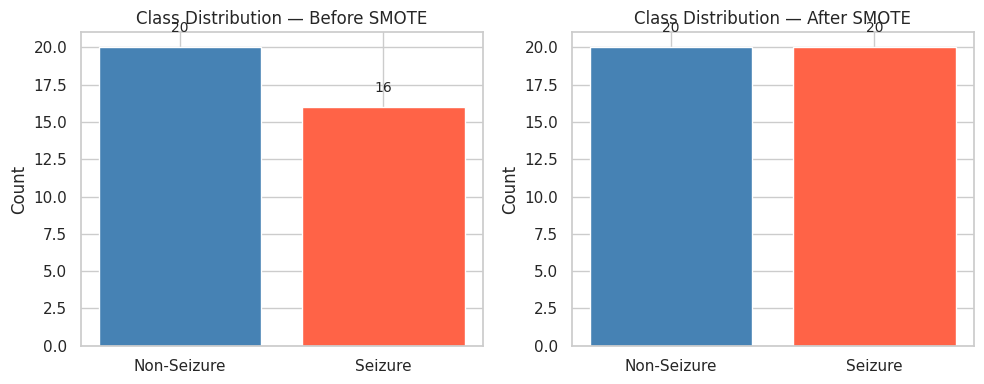

In [68]:
#  SMOTE — Oversample minority (seizure) class 
# Now, SMOTE is applied ONLY on training data (after split).
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_scaled, y_clean)

print("Class distribution AFTER SMOTE:")
unique, counts = np.unique(y_smote, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Non-Seizure' if u == 0 else 'Seizure'
    print(f"  {label}: {c}")

# ── Plot: Before vs After SMOTE ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before = pd.Series(y_clean).value_counts().sort_index()
after  = pd.Series(y_smote).value_counts().sort_index()

axes[0].bar(['Non-Seizure','Seizure'], before.values, color=['steelblue','tomato'])
axes[0].set_title('Class Distribution — Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

axes[1].bar(['Non-Seizure','Seizure'], after.values, color=['steelblue','tomato'])
axes[1].set_title('Class Distribution — After SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

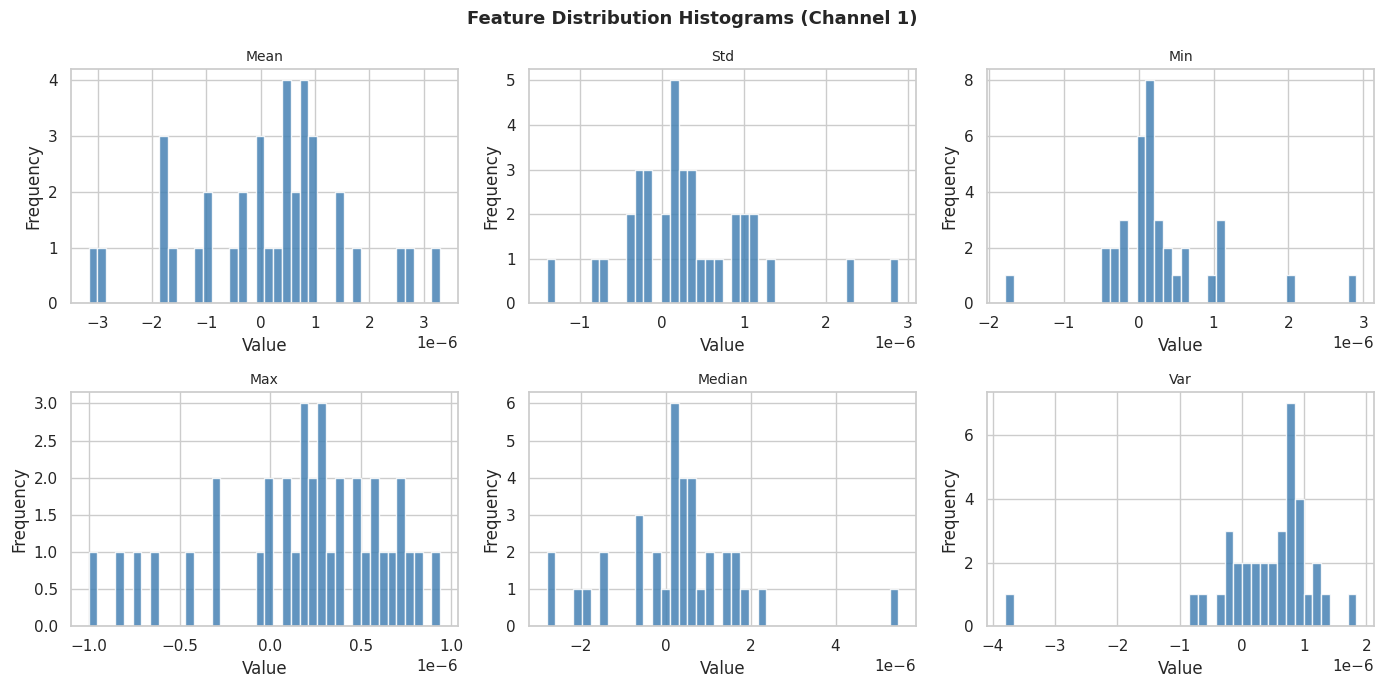

In [71]:
# ── (a) Histogram — Feature Distribution 
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Feature Distribution Histograms (Channel 1)', fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flatten(), feature_cols[:6]):
    ax.hist(df[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(feat.split('_')[-1].capitalize(), fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

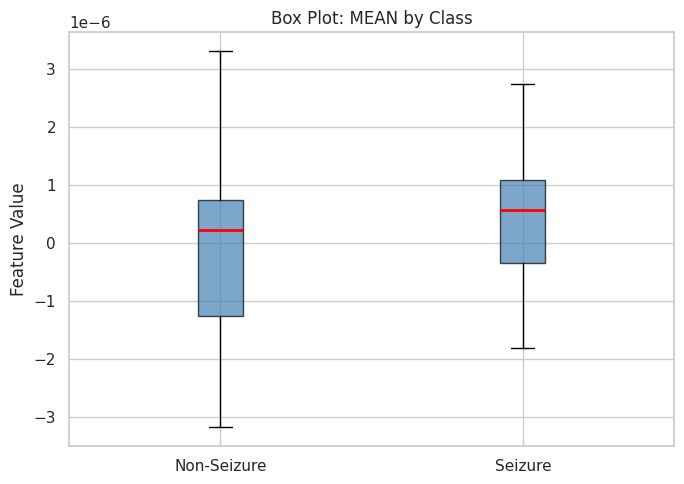

In [72]:
#  Box Plot — Seizure vs Non-Seizure 
plot_feat = feature_cols[0]   # use the first feature (channel 1 mean)
fig, ax   = plt.subplots(figsize=(7, 5))

data_0 = df.loc[df['label']==0, plot_feat]
data_1 = df.loc[df['label']==1, plot_feat]

ax.boxplot([data_0, data_1], labels=['Non-Seizure', 'Seizure'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
ax.set_title(f'Box Plot: {plot_feat.split("_")[-1].upper()} by Class', fontsize=12)
ax.set_ylabel('Feature Value')
plt.tight_layout()
plt.show()

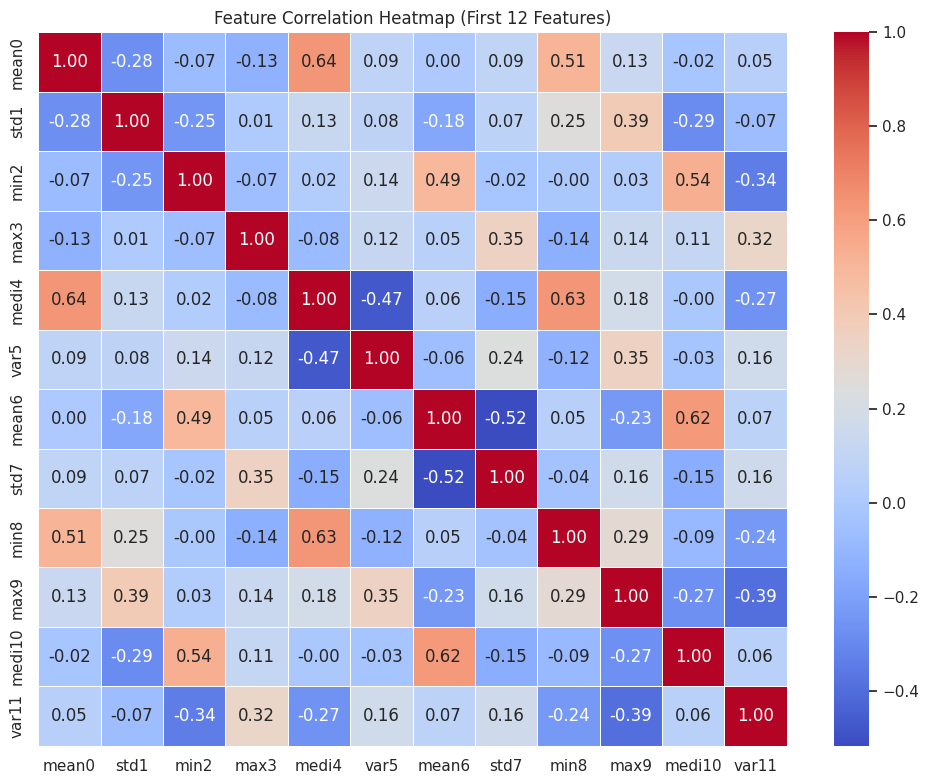

In [73]:
# Correlation Heatmap 
# Use first 12 features for readability
corr = df[feature_cols[:12]].corr()

short_names = [c.split('_')[-1][:4] + str(i) for i, c in enumerate(feature_cols[:12])]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=short_names, yticklabels=short_names,
            ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap (First 12 Features)', fontsize=12)
plt.tight_layout()
plt.show()

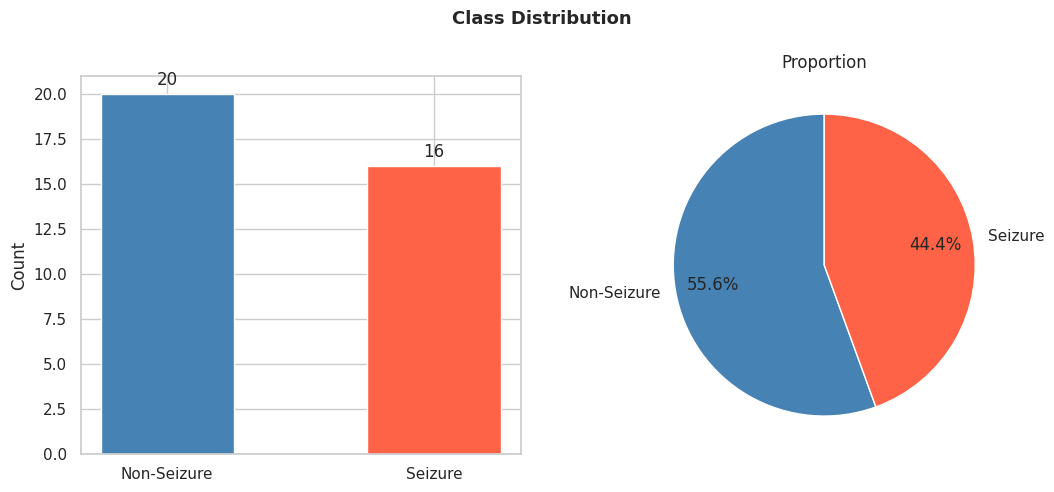

In [74]:
# Class Distribution Plot
counts = pd.Series(y_clean).value_counts().sort_index()
labels = ['Non-Seizure', 'Seizure']
colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Class Distribution', fontsize=13, fontweight='bold')

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75)
axes[1].set_title('Proportion')

plt.tight_layout()
plt.show()

In [76]:
# ── Train / Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean        # keep class proportions equal in both splits
)

print(f"Train set : {X_train.shape[0]} samples")
print(f"Test set  : {X_test.shape[0]} samples")
print(f"Train class dist: {np.bincount(y_train)}")
print(f"Test  class dist: {np.bincount(y_test)}")

Train set : 28 samples
Test set  : 8 samples
Train class dist: [16 12]
Test  class dist: [4 4]


In [77]:
# ── Apply SMOTE on Training Data ONLY 
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Training set after SMOTE : {X_train_sm.shape[0]} samples")
print(f"Train class dist (SMOTE) : {np.bincount(y_train_sm)}")
print("\nTest set is NOT touched by SMOTE ")

Training set after SMOTE : 32 samples
Train class dist (SMOTE) : [16 16]

Test set is NOT touched by SMOTE 


In [78]:
# ── Train Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_depth=10,        # limit depth to avoid overfitting
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf_model.fit(X_train_sm, y_train_sm)
print("Random Forest trained ")

Random Forest trained 


In [79]:
# ── Evaluate Random Forest 
y_pred_rf   = rf_model.predict(X_test)
y_prob_rf   = rf_model.predict_proba(X_test)[:, 1]   # probability for class 1

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, zero_division=0)
rf_rec  = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1   = f1_score(y_test, y_pred_rf, zero_division=0)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print("=== Random Forest Results ===")
print(f"  Accuracy  : {rf_acc:.4f}")
print(f"  Precision : {rf_prec:.4f}")
print(f"  Recall    : {rf_rec:.4f}")
print(f"  F1-Score  : {rf_f1:.4f}")
print(f"  AUC-ROC   : {auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Non-Seizure','Seizure']))

=== Random Forest Results ===
  Accuracy  : 0.3750
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  AUC-ROC   : 0.1562

Classification Report:
              precision    recall  f1-score   support

 Non-Seizure       0.43      0.75      0.55         4
     Seizure       0.00      0.00      0.00         4

    accuracy                           0.38         8
   macro avg       0.21      0.38      0.27         8
weighted avg       0.21      0.38      0.27         8



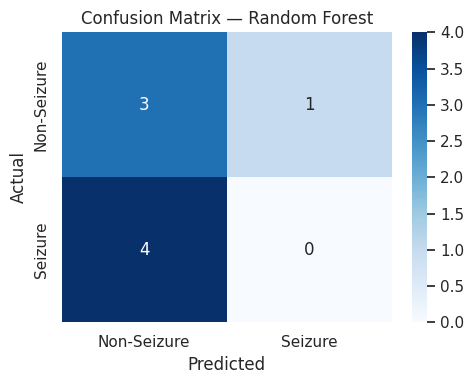

In [80]:
# ── Confusion Matrix — Random Forest 
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Seizure','Seizure'],
            yticklabels=['Non-Seizure','Seizure'], ax=ax)
ax.set_title('Confusion Matrix — Random Forest')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [81]:
# Reshape data for CNN: (samples, timesteps, 1) 
X_train_cnn = X_train_sm.reshape(X_train_sm.shape[0], X_train_sm.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"CNN train shape: {X_train_cnn.shape}")
print(f"CNN test shape : {X_test_cnn.shape}")

CNN train shape: (32, 138, 1)
CNN test shape : (8, 138, 1)


In [82]:
# Build 1D CNN Model 
def build_cnn(input_length):
    model = Sequential([

        # Block 1: First convolutional block
        Conv1D(filters=32, kernel_size=3, activation='relu',
               padding='same', input_shape=(input_length, 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Block 2: Second convolutional block (deeper features)
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Flatten and classify
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')   # binary output
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


cnn_model = build_cnn(X_train_cnn.shape[1])
cnn_model.summary()

2026-05-11 20:09:11.826626: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 138, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 138, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 69, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 69, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 69, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 69, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 34, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 34, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2176)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       139,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,113 (570.75 KB)

 Trainable params: 145,921 (570.00 KB)

 Non-trainable params: 192 (768.00 B)

In [83]:
# ── Train CNN 
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_cnn, y_train_sm,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5185 - loss: 1.3295 - val_accuracy: 0.2000 - val_loss: 0.7123
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5556 - loss: 1.0265 - val_accuracy: 0.6000 - val_loss: 0.6627
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6667 - loss: 0.6370 - val_accuracy: 1.0000 - val_loss: 0.6302
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.6667 - loss: 0.7504 - val_accuracy: 0.8000 - val_loss: 0.6166
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7778 - loss: 0.5170 - val_accuracy: 0.8000 - val_loss: 0.6157
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7407 - loss: 0.5645 - val_accuracy: 0.8000 - val_loss: 0.6177
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8889 - loss: 0.2779 - val_accuracy: 0.8000 - val_loss: 0.6183
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8148 - loss: 0.3697 - val_accuracy: 0.8000 - val_loss: 0.

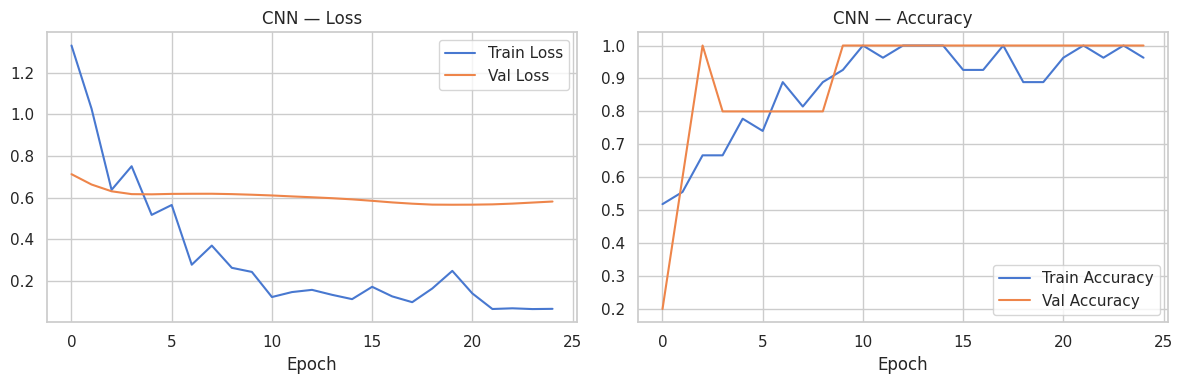

In [84]:
# ── Training History Plots 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('CNN — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('CNN — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [85]:
# ── Evaluate CNN 
y_prob_cnn = cnn_model.predict(X_test_cnn).flatten()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

cnn_acc  = accuracy_score(y_test, y_pred_cnn)
cnn_prec = precision_score(y_test, y_pred_cnn, zero_division=0)
cnn_rec  = recall_score(y_test, y_pred_cnn, zero_division=0)
cnn_f1   = f1_score(y_test, y_pred_cnn, zero_division=0)

fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_prob_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

print("=== CNN Results ===")
print(f"  Accuracy  : {cnn_acc:.4f}")
print(f"  Precision : {cnn_prec:.4f}")
print(f"  Recall    : {cnn_rec:.4f}")
print(f"  F1-Score  : {cnn_f1:.4f}")
print(f"  AUC-ROC   : {auc_cnn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnn,
                            target_names=['Non-Seizure','Seizure']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
=== CNN Results ===
  Accuracy  : 0.6250
  Precision : 1.0000
  Recall    : 0.2500
  F1-Score  : 0.4000
  AUC-ROC   : 0.3750

Classification Report:
              precision    recall  f1-score   support

 Non-Seizure       0.57      1.00      0.73         4
     Seizure       1.00      0.25      0.40         4

    accuracy                           0.62         8
   macro avg       0.79      0.62      0.56         8
weighted avg       0.79      0.62      0.56         8



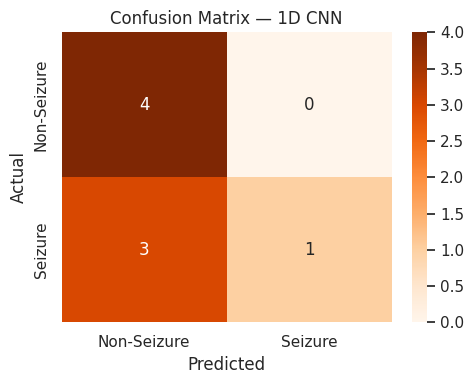

In [86]:
# ── Confusion Matrix — CNN 
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Seizure','Seizure'],
            yticklabels=['Non-Seizure','Seizure'], ax=ax)
ax.set_title('Confusion Matrix — 1D CNN')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

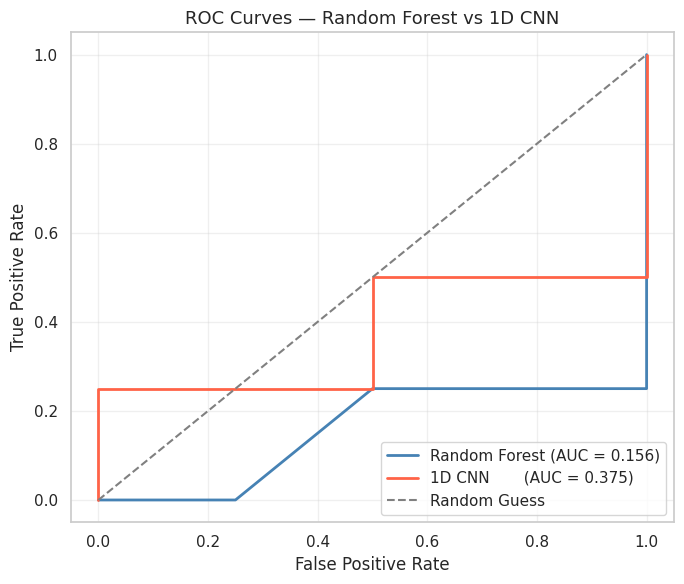

In [87]:
# ── ROC Curves — Both Models 
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_rf,  tpr_rf,  color='steelblue', lw=2,
        label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot(fpr_cnn, tpr_cnn, color='tomato',    lw=2,
        label=f'1D CNN       (AUC = {auc_cnn:.3f})')
ax.plot([0,1], [0,1], color='grey', linestyle='--', label='Random Guess')

ax.set_title('ROC Curves — Random Forest vs 1D CNN', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
# ── Comparison Table 
comparison_df = pd.DataFrame({
    'Model'    : ['Random Forest', '1D CNN'],
    'Accuracy' : [round(rf_acc,  4), round(cnn_acc,  4)],
    'Precision': [round(rf_prec, 4), round(cnn_prec, 4)],
    'Recall'   : [round(rf_rec,  4), round(cnn_rec,  4)],
    'F1-Score' : [round(rf_f1,   4), round(cnn_f1,   4)],
    'AUC-ROC'  : [round(auc_rf,  4), round(auc_cnn,  4)],
})

print("=== Model Comparison Table ===")
print(comparison_df.to_string(index=False))

=== Model Comparison Table ===
        Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Random Forest     0.375        0.0    0.00       0.0   0.1562
       1D CNN     0.625        1.0    0.25       0.4   0.3750


In [89]:

# ── Save Random Forest with joblib 
joblib.dump(rf_model, 'random_forest_seizure.pkl')
joblib.dump(scaler,   'scaler_seizure.pkl')          # save scaler too
print("Random Forest model saved → random_forest_seizure.pkl")
print("Scaler saved             → scaler_seizure.pkl")

# ── Save CNN in .h5 format 
cnn_model.save('cnn_seizure_model.h5')
print("CNN model saved          → cnn_seizure_model.h5")

Random Forest model saved → random_forest_seizure.pkl
Scaler saved             → scaler_seizure.pkl
CNN model saved          → cnn_seizure_model.h5


In [91]:
def predict_from_edf(edf_path, model_type='rf'):
    """
    Load an EDF file, extract features, and predict seizure/non-seizure
    for each 10-second window.

    Parameters
    ----------
    edf_path   : str
        Path to the EDF file

    model_type : str
        'rf'  -> Random Forest
        'cnn' -> CNN model

    Returns
    -------
    predictions : list of dictionaries
    """

    import joblib
    import pandas as pd
    import numpy as np

    # ── 1. Read EDF ──────────────────────────────────────────────────────

    signals, ch_names, sr, raw = read_edf_signals(edf_path)

    if signals is None:
        print("Error: Could not read EDF file.")
        return []

    # Keep first 23 EEG channels
    signals = signals[:23]

    n_ch, n_samples = signals.shape

    # Window size = 10 seconds
    WINDOW_SEC = 10
    window_size = sr * WINDOW_SEC

    # ── 2. Load saved scaler ────────────────────────────────────────────

    loaded_scaler = joblib.load('scaler_seizure.pkl')

    # ── 3. Load model ONCE (faster) ────────────────────────────────────

    if model_type == 'rf':

        loaded_model = joblib.load(
            'random_forest_seizure.pkl'
        )

    elif model_type == 'cnn':

        from tensorflow.keras.models import load_model

        loaded_model = load_model(
            'cnn_seizure_model.h5'
        )

    else:

        print("Invalid model_type. Use 'rf' or 'cnn'")
        return []

    # ── 4. Predict each window ─────────────────────────────────────────

    results = []

    window_idx = 0

    for start in range(
        0,
        n_samples - window_size + 1,
        window_size
    ):

        end = start + window_size

        # Extract window
        window = signals[:, start:end]

        # Feature extraction
        feat = extract_features_from_window(window)

        feat = feat.reshape(1, -1)

        # Normalize
        feat_scaled = loaded_scaler.transform(feat)

        # ── Random Forest ────────────────────────────────────────────

        if model_type == 'rf':

            pred = loaded_model.predict(
                feat_scaled
            )[0]

            prob = loaded_model.predict_proba(
                feat_scaled
            )[0][1]

        # ── CNN ──────────────────────────────────────────────────────

        else:

            feat_cnn = feat_scaled.reshape(
                1,
                feat_scaled.shape[1],
                1
            )

            prob = float(
                loaded_model.predict(
                    feat_cnn,
                    verbose=0
                )[0][0]
            )

            pred = 1 if prob >= 0.5 else 0

        # ── Save result ──────────────────────────────────────────────

        results.append({

            'window': window_idx,

            'start_sec': round(start / sr, 2),

            'end_sec': round(end / sr, 2),

            'prediction':
                'Seizure'
                if pred == 1
                else 'Non-Seizure',

            'probability':
                round(float(prob), 4)
        })

        window_idx += 1

    return results


# ── Demo prediction on first EDF file ─────────────────────────────────────

print("Running prediction on sample file...")

preds = predict_from_edf(
    all_edf_files[0],
    model_type='rf'
)

pred_df = pd.DataFrame(preds)

print("\nTotal windows analyzed:",
      len(pred_df))

print("Seizure windows found:",
      (pred_df['prediction'] == 'Seizure').sum())

print("\nFirst 5 windows:")

print(pred_df.head())

Running prediction on sample file...

Total windows analyzed: 360
Seizure windows found: 0

First 5 windows:
   window  start_sec  end_sec   prediction  probability
0       0        0.0     10.0  Non-Seizure         0.35
1       1       10.0     20.0  Non-Seizure         0.34
2       2       20.0     30.0  Non-Seizure         0.33
3       3       30.0     40.0  Non-Seizure         0.35
4       4       40.0     50.0  Non-Seizure         0.37


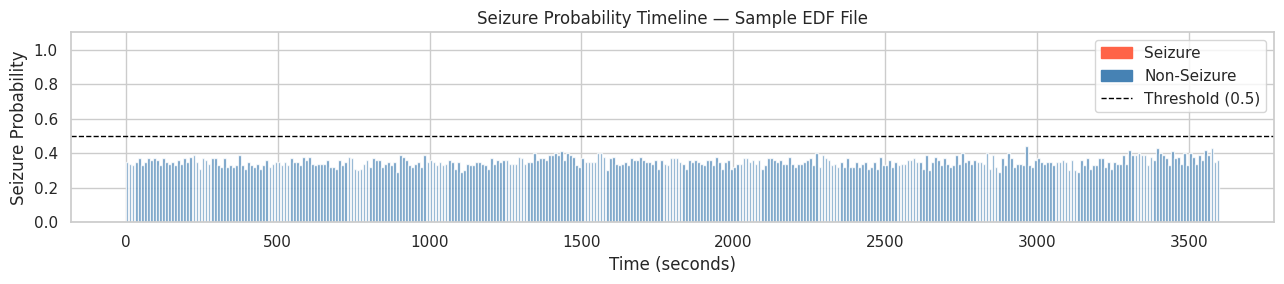

In [92]:
# ── Visualize Prediction Timeline 
if len(pred_df) > 0:
    colors = ['tomato' if p == 'Seizure' else 'steelblue'
              for p in pred_df['prediction']]

    fig, ax = plt.subplots(figsize=(13, 3))
    ax.bar(pred_df['start_sec'], pred_df['probability'],
           width=WINDOW_SEC * 0.9, color=colors, alpha=0.8, align='edge')
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold (0.5)')
    ax.set_title('Seizure Probability Timeline — Sample EDF File', fontsize=12)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Seizure Probability')
    ax.set_ylim(0, 1.1)

    red_patch  = mpatches.Patch(color='tomato',    label='Seizure')
    blue_patch = mpatches.Patch(color='steelblue', label='Non-Seizure')
    ax.legend(handles=[red_patch, blue_patch, ax.get_lines()[0]], loc='upper right')

    plt.tight_layout()
    plt.show()